# Hack4Her - Churn Hunters

### Equipo: Las Tortugas Hackatecas

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
clientes=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/Clientes.csv')
coolers=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/Coolers.csv')
churntest=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/sales_churn_test.csv')
churntrain=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/sales_churn_train.csv')

### Coolers

In [ ]:
coolers.head()

,customer_id,calmonth,num_coolers,num_doors
0,f20e2ea1ca08aceaa24be958f5bfa909c8decda5b6eb8c...,202408,4.0,6
1,a0cbd7668eeae607a12e83411a61b54b57531e14a19d12...,202504,1.0,2
2,ba9cbf8aea2f4619942eb6c0d0e17ebd8bbe31d22b65de...,202504,3.0,5
3,853ab01b0e00dae71612951dc1c4353f4fac482b8de0c7...,202408,1.0,1
4,8c98380fd9d552420b6d7bde9f66d262a020ba83e19b06...,202408,2.0,3


In [ ]:
# revisar duplicados
coolers.duplicated().sum()

np.int64(148)

In [ ]:
coolers.drop_duplicates(inplace=True)

In [ ]:
coolers.shape # revisar cant registros

(4636528, 4)

In [ ]:
coolers.isna().sum()

,0
customer_id,0
calmonth,0
num_coolers,0
num_doors,0


### Churntrain

In [ ]:
churntrain.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0


In [ ]:
churntrain.duplicated().sum()

np.int64(0)

In [ ]:
churntrain.shape

(5030534, 5)

In [ ]:
churntrain.isna().sum()

,0
customer_id,0
calmonth,0
num_transacciones,0
uni_boxes_sold_m,0
target,0


### Clientes

In [ ]:
clientes.head()

,customer_id,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,0c99f37a704e46368b28440a66a44cc988ee3c71b64aa5...,Aguascalientes,Abarrotes y bodegas,Mini
1,a9ea72c0f0a06c6c97714059f339fc65aa6fe8e122a9de...,Aguascalientes,Abarrotes y bodegas,Mediano
2,b1a6b0c122e1e549500512c7d6ae253ea773d59e4a8781...,Aguascalientes,Abarrotes y bodegas,Gigante
3,2964dd973f3387fdf2bd2f07149e900b780639624b5117...,Aguascalientes,Kiosco,Mini
4,9a6f4fb27d8ab6fc5290f0820cfec6c5782d6f7cba167a...,Aguascalientes,Licorería,Mini


In [ ]:
clientes.duplicated().sum()

np.int64(0)

In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371727 entries, 0 to 371726
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             371727 non-null  object
 1   territory_d             371727 non-null  object
 2   comercial_subchannel_d  371727 non-null  object
 3   rtm_customer_size_d     356289 non-null  object
dtypes: object(4)
memory usage: 11.3+ MB


In [ ]:
clientes['comercial_subchannel_d'].value_counts()

,count
comercial_subchannel_d,
Hogares,128988
Abarrotes y bodegas,86562
Kiosco,75969
Licorería,31498
Verdulería,12236
Farmacia,6893
Tiendas de carne/pollo/pescado,6885
Tienda orgánica,6148
Tortillería,6104


In [ ]:
(clientes['rtm_customer_size_d'].isnull().sum()/len(clientes))*100

np.float64(4.153047801208952)

In [ ]:
# eliminando registros nulos, regresentan el 4% de los datos
clientes.dropna(inplace=True)

### Unificar dataset

In [ ]:
merged_churntrain_coolers = pd.merge(churntrain, coolers, on=['customer_id', 'calmonth'], how='left')
final_merge=pd.merge(merged_churntrain_coolers,clientes,on='customer_id',how='left')
final_merge.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0,1.0,1.0,Saltillo,Hogares,Mini
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0,1.0,1.0,Saltillo,Hogares,Mini
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0,1.0,1.0,Saltillo,Hogares,Mini
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0,1.0,1.0,Saltillo,Hogares,Mini
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0,1.0,1.0,Saltillo,Hogares,Mini


In [ ]:
final_merge.shape

(5031897, 10)

In [ ]:
final_merge['rtm_customer_size_d'].value_counts()

,count
rtm_customer_size_d,
Mediano,1826464
Pequeño,1341114
Mini,913152
Grande,577743
Gigante,373424


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

rating=['Mini','Pequeño','Mediano','Grande','Gigante']
encoder=OrdinalEncoder(categories=[rating])
final_merge['rtm_customer_size_d']=encoder.fit_transform(final_merge[['rtm_customer_size_d']])
final_merge.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0,1.0,1.0,Saltillo,Hogares,0.0
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0,1.0,1.0,Saltillo,Hogares,0.0
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0,1.0,1.0,Saltillo,Hogares,0.0
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0,1.0,1.0,Saltillo,Hogares,0.0
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0,1.0,1.0,Saltillo,Hogares,0.0


In [ ]:
final_merge.isna().sum()

,0
customer_id,0
calmonth,0
num_transacciones,0
uni_boxes_sold_m,0
target,0
num_coolers,714469
num_doors,714469
territory_d,0
comercial_subchannel_d,0
rtm_customer_size_d,0


In [ ]:
final_merge.shape

(5031897, 10)

In [ ]:
(final_merge['num_coolers'].isnull().sum()/len(final_merge))*100

np.float64(14.198800174168907)

In [ ]:
# Identify columns with missing values (num_coolers and num_doors)
columns_to_impute = ['num_coolers', 'num_doors']

print("Missing values before median imputation:")
print(final_merge[columns_to_impute].isna().sum())

# Impute missing values with the median of each column
for col in columns_to_impute:
    median_value = final_merge[col].median()
    final_merge[col].fillna(median_value, inplace=True)
    print(f"Median for {col}: {median_value:.2f}")

print("\nMissing values after median imputation:")
print(final_merge[columns_to_impute].isna().sum())

print("\nFirst 5 rows of final_merge after median imputation:")
print(final_merge.head())

Missing values before median imputation:
num_coolers    714469
num_doors      714469
dtype: int64
Median for num_coolers: 1.00
Median for num_doors: 2.00

Missing values after median imputation:
num_coolers    0
num_doors      0
dtype: int64

First 5 rows of final_merge after median imputation:
                                         customer_id  calmonth  \
0  d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...    202410   
1  d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...    202411   
2  d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...    202412   
3  d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...    202501   
4  d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...    202502   

   num_transacciones  uni_boxes_sold_m  target  num_coolers  num_doors  \
0                 29         65.166068       0          1.0        1.0   
1                 25         56.640400       0          1.0        1.0   
2                 10         21.486900       0          1.0        1.0   
3          

/tmp/ipykernel_8912/1949386689.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_merge[col].fillna(median_value, inplace=True)


In [ ]:
final_merge.isna().sum()

,0
customer_id,0
calmonth,0
num_transacciones,0
uni_boxes_sold_m,0
target,0
num_coolers,0
num_doors,0
territory_d,0
comercial_subchannel_d,0
rtm_customer_size_d,0


## Analisis correlación

<Axes: >

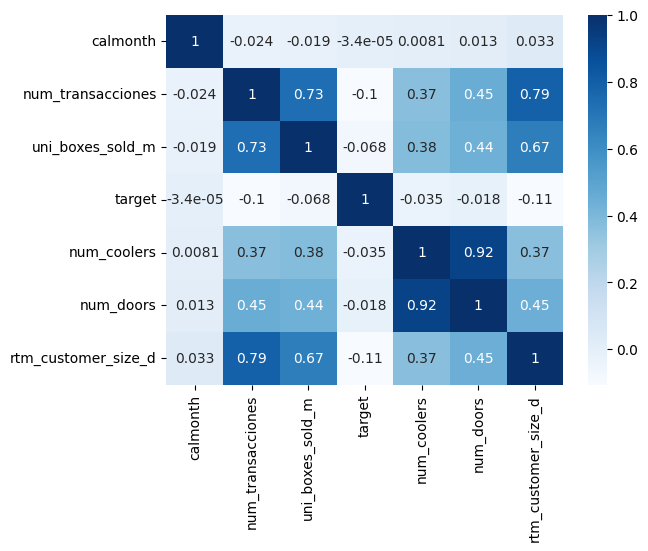

In [ ]:
df_numerico=final_merge.select_dtypes(include=[np.number])
sns.heatmap(df_numerico.corr(),annot=True,cmap='Blues')

In [ ]:
from scipy.stats import chi2_contingency

# Correlation between 'target' and 'territory_d'
contingency_table_territory = pd.crosstab(final_merge['target'], final_merge['territory_d'])
chi2_territory, p_territory, dof_territory, expected_territory = chi2_contingency(contingency_table_territory)

print("Pearson's Chi-squared test for 'target' vs 'territory_d':")
print(f"Chi2 Statistic: {chi2_territory}")
print(f"P-value: {p_territory}")
print(f"Degrees of Freedom: {dof_territory}")
if p_territory < 0.05:
    print("There is a statistically significant association between 'target' and 'territory_d'.")
else:
    print("There is no statistically significant association between 'target' and 'territory_d'.")
print("\n")

# Correlation between 'target' and 'comercial_subchannel_d'
contingency_table_subchannel = pd.crosstab(final_merge['target'], final_merge['comercial_subchannel_d'])
chi2_subchannel, p_subchannel, dof_subchannel, expected_subchannel = chi2_contingency(contingency_table_subchannel)

print("Pearson's Chi-squared test for 'target' vs 'comercial_subchannel_d':")
print(f"Chi2 Statistic: {chi2_subchannel}")
print(f"P-value: {p_subchannel}")
print(f"Degrees of Freedom: {dof_subchannel}")
if p_subchannel < 0.05:
    print("There is a statistically significant association between 'target' and 'comercial_subchannel_d'.")
else:
    print("There is no statistically significant association between 'target' and 'comercial_subchannel_d'.")

Pearson's Chi-squared test for 'target' vs 'territory_d':
Chi2 Statistic: 3388.448755203754
P-value: 0.0
Degrees of Freedom: 24
There is a statistically significant association between 'target' and 'territory_d'.


Pearson's Chi-squared test for 'target' vs 'comercial_subchannel_d':
Chi2 Statistic: 6911.739069791614
P-value: 0.0
Degrees of Freedom: 12
There is a statistically significant association between 'target' and 'comercial_subchannel_d'.


## CODIFICACIÓN

In [ ]:
!pip install category_encoders

In [ ]:
# ============================================================
# PREPARACIÓN + VENTANA MÓVIL N=4 + ENCODING + SPLIT POR CLIENTE
# Desde final_merge
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder

# ------------------------------------------------------------
# 1. Copia desde final_merge
# ------------------------------------------------------------

df_model = final_merge.copy()

df_model.sort_values(
    by=["customer_id", "calmonth"],
    inplace=True
)

print("DataFrame ordenado:")
display(df_model.head())

# ------------------------------------------------------------
# 2. Variables de comportamiento
# ------------------------------------------------------------

behavioral_vars = [
    "num_transacciones",
    "uni_boxes_sold_m",
    "num_coolers",
    "num_doors"
]

# ------------------------------------------------------------
# 3. Crear lags de 1 a 4 meses por cliente
# ------------------------------------------------------------

for var in behavioral_vars:
    for lag in range(1, 5):
        df_model[f"{var}_lag_{lag}"] = (
            df_model
            .groupby("customer_id")[var]
            .shift(lag)
        )

print("DataFrame con lags:")
display(df_model.head())

# ------------------------------------------------------------
# 4. Eliminar filas sin historial suficiente
# ------------------------------------------------------------

df_model.dropna(
    subset=[f"{behavioral_vars[0]}_lag_4"],
    inplace=True
)

print(f"DataFrame después de dropna: {df_model.shape}")
display(df_model.head())

# ------------------------------------------------------------
# 5. Feature Engineering ventana móvil N=4
# ------------------------------------------------------------

for var in behavioral_vars:
    lag_cols = [f"{var}_lag_{i}" for i in range(1, 5)]

    df_model[f"{var}_avg_4m"] = df_model[lag_cols].mean(axis=1)

    df_model[f"{var}_std_4m"] = df_model[lag_cols].std(axis=1)

    df_model[f"{var}_growth_lag1_lag4"] = (
        df_model[f"{var}_lag_1"] - df_model[f"{var}_lag_4"]
    ) / (df_model[f"{var}_lag_4"] + 1e-6)

print("DataFrame con variables engineered:")
display(df_model.head())

# ------------------------------------------------------------
# 6. Limpiar variables categóricas
# ------------------------------------------------------------

cat_cols = [
    "territory_d",
    "comercial_subchannel_d",
    "rtm_customer_size_d"
]

for col in cat_cols:
    df_model[col] = (
        df_model[col]
        .astype("string")
        .fillna("Desconocido")
        .str.strip()
    )

# ------------------------------------------------------------
# 7. Seleccionar columnas para modelo
# ------------------------------------------------------------

engineered_features = [
    col for col in df_model.columns
    if col.endswith(("_avg_4m", "_std_4m", "_growth_lag1_lag4"))
]

columns_to_keep = [
    "customer_id",
    "calmonth",
    "target",
    "territory_d",
    "comercial_subchannel_d",
    "rtm_customer_size_d"
] + engineered_features

df_model_ready = df_model[columns_to_keep].copy()

print("Columnas antes del split:")
print(df_model_ready.columns.tolist())
print("Dimensiones antes del split:", df_model_ready.shape)

# ------------------------------------------------------------
# 8. Split 90/10 por cliente
# ------------------------------------------------------------

X = df_model_ready.drop(columns=["target"])
y = df_model_ready["target"]
groups = df_model_ready["customer_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

train_df = df_model_ready.iloc[train_idx].copy()
test_df = df_model_ready.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

clientes_repetidos = set(train_df["customer_id"]).intersection(
    set(test_df["customer_id"])
)

print("Clientes repetidos entre train y test:", len(clientes_repetidos))

# ------------------------------------------------------------
# 9. Target Encoding manual suavizado
# ------------------------------------------------------------

def target_encode_smooth(train, test, column, target="target", alpha=20):
    global_mean = train[target].mean()

    stats = (
        train
        .groupby(column)[target]
        .agg(["mean", "count"])
    )

    smooth = (
        stats["count"] * stats["mean"] + alpha * global_mean
    ) / (
        stats["count"] + alpha
    )

    train[column + "_te"] = train[column].map(smooth)
    test[column + "_te"] = test[column].map(smooth)

    test[column + "_te"] = test[column + "_te"].fillna(global_mean)

    return train, test

train_df, test_df = target_encode_smooth(
    train_df,
    test_df,
    column="territory_d"
)

train_df, test_df = target_encode_smooth(
    train_df,
    test_df,
    column="comercial_subchannel_d"
)

# Renombrar columnas codificadas
train_df.rename(columns={
    "territory_d_te": "territory_te",
    "comercial_subchannel_d_te": "subchannel_te"
}, inplace=True)

test_df.rename(columns={
    "territory_d_te": "territory_te",
    "comercial_subchannel_d_te": "subchannel_te"
}, inplace=True)

# ------------------------------------------------------------
# 10. Ordinal Encoding para rtm_customer_size_d
# ------------------------------------------------------------

orden_size = [
    "Mini",
    "Pequeño",
    "Mediano",
    "Grande",
    "Gigante"
]

ordinal_encoder = OrdinalEncoder(
    categories=[orden_size],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_df["rtm_customer_size_ord"] = ordinal_encoder.fit_transform(
    train_df[["rtm_customer_size_d"]]
)

test_df["rtm_customer_size_ord"] = ordinal_encoder.transform(
    test_df[["rtm_customer_size_d"]]
)

# ------------------------------------------------------------
# 11. Eliminar variables categóricas originales
# ------------------------------------------------------------

cols_to_drop = [
    "territory_d",
    "comercial_subchannel_d",
    "rtm_customer_size_d"
]

train_model_ready = train_df.drop(columns=cols_to_drop).copy()
test_model_ready = test_df.drop(columns=cols_to_drop).copy()

# ------------------------------------------------------------
# 12. Resultado final
# ------------------------------------------------------------

print("Train final:", train_model_ready.shape)
print("Test final:", test_model_ready.shape)

print("Columnas finales:")
print(train_model_ready.columns.tolist())

display(train_model_ready.head())
display(test_model_ready.head())

# ------------------------------------------------------------
# 13. Separar X/y para modelado
# ------------------------------------------------------------

X_train = train_model_ready.drop(columns=["target"])
y_train = train_model_ready["target"]

X_test = test_model_ready.drop(columns=["target"])
y_test = test_model_ready["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

DataFrame ordenado:


,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d
1467758,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202401,126,377.707500,0,1.0,2.0,Culiacan,Tortillería,0.0
1467759,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202402,2,2.958800,0,1.0,2.0,Culiacan,Tortillería,0.0
1467760,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202403,0,0.000000,1,1.0,2.0,Culiacan,Tortillería,0.0
2956254,00008908998fbc054fa79e72be7b19357253fab910d570...,202401,63,167.586725,0,3.0,3.0,Mesa Central,Mayorista,2.0
2956255,00008908998fbc054fa79e72be7b19357253fab910d570...,202402,72,318.081225,0,3.0,3.0,Mesa Central,Mayorista,2.0


DataFrame con lags:


,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d,...,uni_boxes_sold_m_lag_3,uni_boxes_sold_m_lag_4,num_coolers_lag_1,num_coolers_lag_2,num_coolers_lag_3,num_coolers_lag_4,num_doors_lag_1,num_doors_lag_2,num_doors_lag_3,num_doors_lag_4
1467758,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202401,126,377.707500,0,1.0,2.0,Culiacan,Tortillería,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1467759,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202402,2,2.958800,0,1.0,2.0,Culiacan,Tortillería,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1467760,0000443786ce90b386b37f64ae7ae011f9c2a71733855a...,202403,0,0.000000,1,1.0,2.0,Culiacan,Tortillería,0.0,...,NaN,NaN,1.0,1.0,NaN,NaN,2.0,2.0,NaN,NaN
2956254,00008908998fbc054fa79e72be7b19357253fab910d570...,202401,63,167.586725,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2956255,00008908998fbc054fa79e72be7b19357253fab910d570...,202402,72,318.081225,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,NaN,NaN,3.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN


DataFrame después de dropna: (4088858, 26)


...

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d,...,num_transacciones_growth_lag1_lag4,uni_boxes_sold_m_avg_4m,uni_boxes_sold_m_std_4m,uni_boxes_sold_m_growth_lag1_lag4,num_coolers_avg_4m,num_coolers_std_4m,num_coolers_growth_lag1_lag4,num_doors_avg_4m,num_doors_std_4m,num_doors_growth_lag1_lag4
2956258,00008908998fbc054fa79e72be7b19357253fab910d570...,202405,70,232.546500,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,0.349206,199.462256,79.439111,-0.030159,3.0,0.0,0.0,3.0,0.0,0.0
2956259,00008908998fbc054fa79e72be7b19357253fab910d570...,202406,96,327.422800,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,-0.027778,215.702200,77.363410,-0.268908,3.0,0.0,0.0,3.0,0.0,0.0
2956260,00008908998fbc054fa79e72be7b19357253fab910d570...,202407,89,308.919825,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,0.280000,218.037594,81.513809,1.187944,3.0,0.0,0.0,3.0,0.0,0.0
2956261,00008908998fbc054fa79e72be7b19357253fab910d570...,202408,82,215.649425,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,0.047059,257.855388,75.661987,0.900666,3.0,0.0,0.0,3.0,0.0,0.0
2956262,00008908998fbc054fa79e72be7b19357253fab910d570...,202409,71,297.211500,0,3.0,3.0,Mesa Central,Mayorista,2.0,...,0.171429,271.134638,55.268227,-0.072661,3.0,0.0,0.0,3.0,0.0,0.0


Columnas antes del split:
['customer_id', 'calmonth', 'target', 'territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d', 'num_transacciones_avg_4m', 'num_transacciones_std_4m', 'num_transacciones_growth_lag1_lag4', 'uni_boxes_sold_m_avg_4m', 'uni_boxes_sold_m_std_4m', 'uni_boxes_sold_m_growth_lag1_lag4', 'num_coolers_avg_4m', 'num_coolers_std_4m', 'num_coolers_growth_lag1_lag4', 'num_doors_avg_4m', 'num_doors_std_4m', 'num_doors_growth_lag1_lag4']
Dimensiones antes del split: (4088858, 18)
Train: (3679337, 18)
Test: (409521, 18)
Clientes repetidos entre train y test: 0
Train final: (3679337, 18)
Test final: (409521, 18)
Columnas finales:
['customer_id', 'calmonth', 'target', 'num_transacciones_avg_4m', 'num_transacciones_std_4m', 'num_transacciones_growth_lag1_lag4', 'uni_boxes_sold_m_avg_4m', 'uni_boxes_sold_m_std_4m', 'uni_boxes_sold_m_growth_lag1_lag4', 'num_coolers_avg_4m', 'num_coolers_std_4m', 'num_coolers_growth_lag1_lag4', 'num_doors_avg_4m', 'num_doors_std_4m', 'num_doo

,customer_id,calmonth,target,num_transacciones_avg_4m,num_transacciones_std_4m,num_transacciones_growth_lag1_lag4,uni_boxes_sold_m_avg_4m,uni_boxes_sold_m_std_4m,uni_boxes_sold_m_growth_lag1_lag4,num_coolers_avg_4m,num_coolers_std_4m,num_coolers_growth_lag1_lag4,num_doors_avg_4m,num_doors_std_4m,num_doors_growth_lag1_lag4,territory_te,subchannel_te,rtm_customer_size_ord
2956258,00008908998fbc054fa79e72be7b19357253fab910d570...,202405,0,73.75,9.069179,0.349206,199.462256,79.439111,-0.030159,3.0,0.0,0.0,3.0,0.0,0.0,0.005704,0.003795,-1.0
2956259,00008908998fbc054fa79e72be7b19357253fab910d570...,202406,0,75.50,6.658328,-0.027778,215.702200,77.363410,-0.268908,3.0,0.0,0.0,3.0,0.0,0.0,0.005704,0.003795,-1.0
2956260,00008908998fbc054fa79e72be7b19357253fab910d570...,202407,0,81.50,11.503623,0.280000,218.037594,81.513809,1.187944,3.0,0.0,0.0,3.0,0.0,0.0,0.005704,0.003795,-1.0
2956261,00008908998fbc054fa79e72be7b19357253fab910d570...,202408,0,85.00,10.984838,0.047059,257.855388,75.661987,0.900666,3.0,0.0,0.0,3.0,0.0,0.0,0.005704,0.003795,-1.0
2956262,00008908998fbc054fa79e72be7b19357253fab910d570...,202409,0,84.25,11.086779,0.171429,271.134638,55.268227,-0.072661,3.0,0.0,0.0,3.0,0.0,0.0,0.005704,0.003795,-1.0


,customer_id,calmonth,target,num_transacciones_avg_4m,num_transacciones_std_4m,num_transacciones_growth_lag1_lag4,uni_boxes_sold_m_avg_4m,uni_boxes_sold_m_std_4m,uni_boxes_sold_m_growth_lag1_lag4,num_coolers_avg_4m,num_coolers_std_4m,num_coolers_growth_lag1_lag4,num_doors_avg_4m,num_doors_std_4m,num_doors_growth_lag1_lag4,territory_te,subchannel_te,rtm_customer_size_ord
3427683,00026b024d339780d0ce723f4f1d394088490939598808...,202405,0,27.75,10.307764,0.720000,39.957874,7.930863,-0.066719,1.0,0.0,0.0,1.0,0.0,0.0,0.002363,0.007511,-1.0
3427684,00026b024d339780d0ce723f4f1d394088490939598808...,202406,0,26.25,11.236103,-0.136364,37.350843,5.796944,0.044923,1.0,0.0,0.0,1.0,0.0,0.0,0.002363,0.007511,-1.0
3427685,00026b024d339780d0ce723f4f1d394088490939598808...,202407,0,27.50,10.878113,0.285714,37.541099,5.751683,0.193132,1.0,0.0,0.0,1.0,0.0,0.0,0.002363,0.007511,-1.0
3427686,00026b024d339780d0ce723f4f1d394088490939598808...,202408,0,29.00,10.066446,-0.372093,41.065029,4.447832,0.001373,1.0,0.0,0.0,1.0,0.0,0.0,0.002363,0.007511,-1.0
3427687,00026b024d339780d0ce723f4f1d394088490939598808...,202409,0,21.75,6.396614,-0.263158,35.642592,9.072777,-0.384278,1.0,0.0,0.0,1.0,0.0,0.0,0.002363,0.007511,-1.0


X_train: (3679337, 17)
y_train: (3679337,)
X_test: (409521, 17)
y_test: (409521,)


## Selección de variables

X_train para selección: (3679337, 15)
X_test para selección: (409521, 15)
[LightGBM] [Info] Number of positive: 28094, number of negative: 3651243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.471476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1892
[LightGBM] [Info] Number of data points in the train set: 3679337, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
ROC-AUC LightGBM base: 0.9658


,feature,importance
0,uni_boxes_sold_m_avg_4m,1145
1,territory_te,1108
2,num_transacciones_avg_4m,1084
3,num_transacciones_growth_lag1_lag4,1027
4,uni_boxes_sold_m_growth_lag1_lag4,883
5,num_transacciones_std_4m,869
6,uni_boxes_sold_m_std_4m,842
7,subchannel_te,620
8,num_doors_avg_4m,521
9,num_doors_growth_lag1_lag4,293


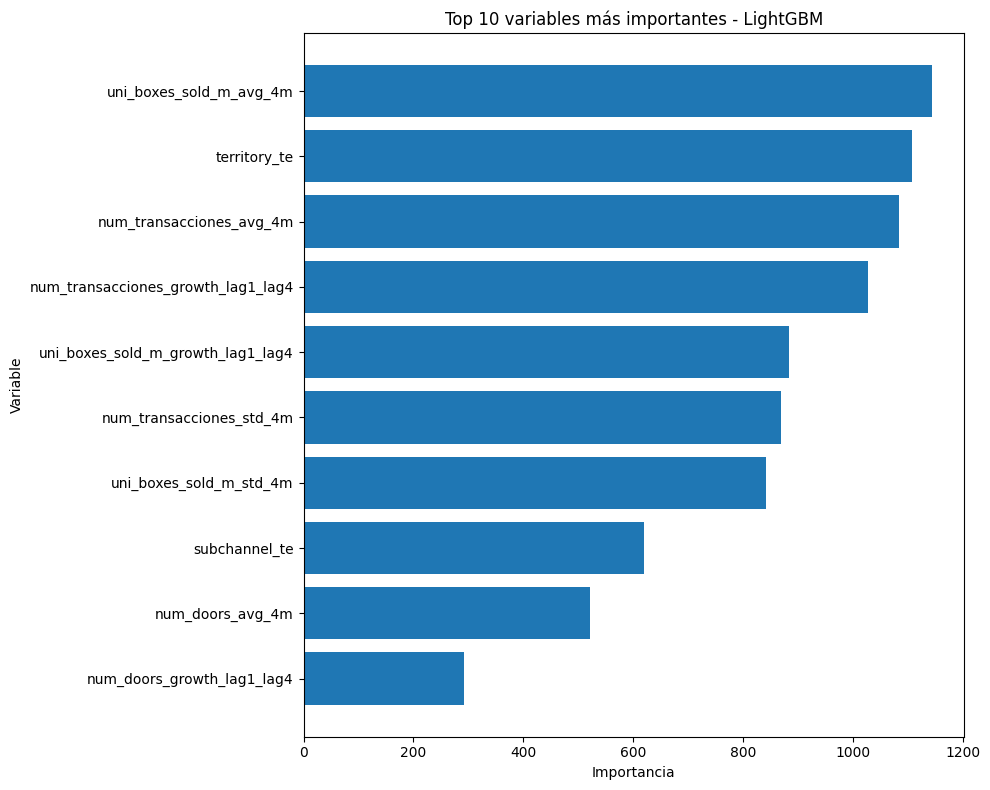

Variables seleccionadas:
['uni_boxes_sold_m_avg_4m', 'territory_te', 'num_transacciones_avg_4m', 'num_transacciones_growth_lag1_lag4', 'uni_boxes_sold_m_growth_lag1_lag4', 'num_transacciones_std_4m', 'uni_boxes_sold_m_std_4m', 'subchannel_te', 'num_doors_avg_4m', 'num_doors_growth_lag1_lag4']
X_train_top: (3679337, 10)
X_test_top: (409521, 10)


In [ ]:
# ============================================================
# SELECCIÓN DE VARIABLES CON LIGHTGBM
# ============================================================

!pip install lightgbm -q

import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report

# ------------------------------------------------------------
# 1. Quitar columnas que no deben entrar al modelo
# ------------------------------------------------------------

cols_no_model = ["customer_id", "calmonth"]

X_train_sel = X_train.drop(columns=cols_no_model, errors="ignore")
X_test_sel = X_test.drop(columns=cols_no_model, errors="ignore")

print("X_train para selección:", X_train_sel.shape)
print("X_test para selección:", X_test_sel.shape)

# ------------------------------------------------------------
# 2. Entrenar LightGBM base para obtener importancia
# ------------------------------------------------------------

lgbm_selector = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_selector.fit(X_train_sel, y_train)

# ------------------------------------------------------------
# 3. Evaluación rápida
# ------------------------------------------------------------

y_proba = lgbm_selector.predict_proba(X_test_sel)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC LightGBM base:", round(auc, 4))

# ------------------------------------------------------------
# 4. Tabla de importancia de variables
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "feature": X_train_sel.columns,
    "importance": lgbm_selector.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

# ------------------------------------------------------------
# 5. Gráfica Top 25 variables
# ------------------------------------------------------------

top_n = 10

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1]
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title(f"Top {top_n} variables más importantes - LightGBM")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Seleccionar mejores variables
# ------------------------------------------------------------

top_features = (
    importance_df
    .query("importance > 0")
    .head(top_n)["feature"]
    .tolist()
)

print("Variables seleccionadas:")
print(top_features)

# ------------------------------------------------------------
# 7. Crear datasets finales con variables seleccionadas
# ------------------------------------------------------------

X_train_top = X_train_sel[top_features].copy()
X_test_top = X_test_sel[top_features].copy()

print("X_train_top:", X_train_top.shape)
print("X_test_top:", X_test_top.shape)

## Modelo

VARIABLES UTILIZADAS
['uni_boxes_sold_m_avg_4m', 'territory_te', 'num_transacciones_avg_4m', 'num_transacciones_growth_lag1_lag4', 'uni_boxes_sold_m_growth_lag1_lag4', 'num_transacciones_std_4m', 'uni_boxes_sold_m_std_4m', 'subchannel_te', 'num_doors_avg_4m', 'num_doors_growth_lag1_lag4']
Número de variables: 10

Train: (3679337, 10)
Test: (409521, 10)

LOGISTIC REGRESSION
ROC-AUC: 0.9316
PR-AUC: 0.1064

Classification report Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90    406452
           1       0.04      0.91      0.07      3069

    accuracy                           0.81    409521
   macro avg       0.52      0.86      0.48    409521
weighted avg       0.99      0.81      0.89    409521


LIGHTGBM
[LightGBM] [Info] Number of positive: 28094, number of negative: 3651243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.126039 seconds.
You can set `force_row_wise=true` t

,threshold,precision,recall,f1,clientes_marcados,porcentaje_marcado
0,0.005,0.008825,0.999022,0.017495,347437,84.84
1,0.010,0.009878,0.996742,0.019561,309690,75.62
2,0.020,0.011857,0.994461,0.023435,257398,62.85
3,0.030,0.013787,0.991854,0.027196,220784,53.91
4,0.050,0.017261,0.986641,0.033929,175424,42.84
5,0.100,0.024566,0.975888,0.047925,121918,29.77
6,0.150,0.031196,0.968394,0.060444,95270,23.26
7,0.200,0.037474,0.959922,0.072132,78615,19.20
8,0.300,0.049563,0.937765,0.094151,58067,14.18
9,0.500,0.076992,0.892147,0.141751,35562,8.68



Mejor threshold por F1: 0.5

RESULTADOS FINALES LIGHTGBM
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    406452
           1       0.08      0.89      0.14      3069

    accuracy                           0.92    409521
   macro avg       0.54      0.91      0.55    409521
weighted avg       0.99      0.92      0.95    409521

Matriz de confusión:
[[373628  32824]
 [   331   2738]]

TOP VARIABLES


,variable,importance
0,num_transacciones_avg_4m,2931
1,uni_boxes_sold_m_avg_4m,2751
2,num_transacciones_growth_lag1_lag4,2725
3,territory_te,2645
4,uni_boxes_sold_m_growth_lag1_lag4,2541
5,num_transacciones_std_4m,2444
6,uni_boxes_sold_m_std_4m,2422
7,num_doors_avg_4m,1664
8,subchannel_te,1522
9,num_doors_growth_lag1_lag4,1295


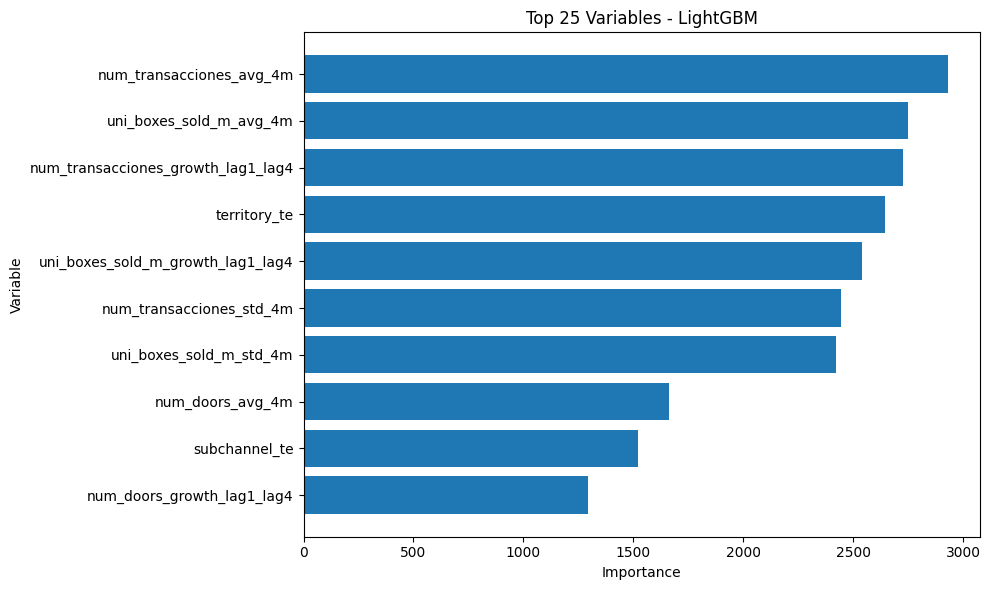


RESUMEN DE ESTRATEGIAS DE INTERVENCIÓN


,estrategia,threshold,clientes_a_intervenir,porcentaje_clientes,churns_detectados,total_churns_reales,recall_churn,precision
0,Agresiva,0.1,121918,29.77,2995,3069,0.9759,0.0246
1,Balanceada,0.3,58067,14.18,2878,3069,0.9378,0.0496
2,Conservadora,0.5,35562,8.68,2738,3069,0.8921,0.0770



RESUMEN POR NIVEL DE RIESGO


,risk_level,clientes,prob_promedio,churn_real
0,Alto,35562,76.00,2738
1,Bajo,287603,2.67,74
2,Bajo vigilado,63851,17.54,117
3,Medio,22505,38.89,140



CLIENTES DE MAYOR RIESGO


,customer_id,calmonth,churn_probability_pct,risk_level,recommended_action,target
1578849,d244e98d977cef318f51222801d0045f49fd4c4f954acb...,202503,99.78,Alto,Visita comercial inmediata + oferta personalizada,1
266693,8968ccb384e8d124ff51b5a4c7545c891b75aebb1eddf2...,202503,99.78,Alto,Visita comercial inmediata + oferta personalizada,1
2880668,aed861e985e3b1397cf204fe62d718f2717b8bc980e0a5...,202410,99.78,Alto,Visita comercial inmediata + oferta personalizada,1
4107101,446693325fb6665b432edab18865fdfc5bb599c2c93882...,202409,99.76,Alto,Visita comercial inmediata + oferta personalizada,1
137615,c4dccf90e3de8f0e33dd48da73c09fe51fedc6702ca47c...,202406,99.76,Alto,Visita comercial inmediata + oferta personalizada,1
1516109,c2b81e00531c53156d93104929f15a6d0c5e0056a546bf...,202502,99.76,Alto,Visita comercial inmediata + oferta personalizada,0
157123,30dba6c482243768d1a99dc2b56f473b8c1963cd1a0552...,202508,99.76,Alto,Visita comercial inmediata + oferta personalizada,1
2207096,8f47701c161e3347634003ad1ee5d68e54f9690c71e48e...,202506,99.76,Alto,Visita comercial inmediata + oferta personalizada,0
2838600,d0516f7300c81435aa8b6ee01783266bc3e96df08075d3...,202509,99.76,Alto,Visita comercial inmediata + oferta personalizada,1
17391,a34f74c41e23a59d626825e6908d09364e49ba1ae12bcc...,202506,99.75,Alto,Visita comercial inmediata + oferta personalizada,1



SHAP


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


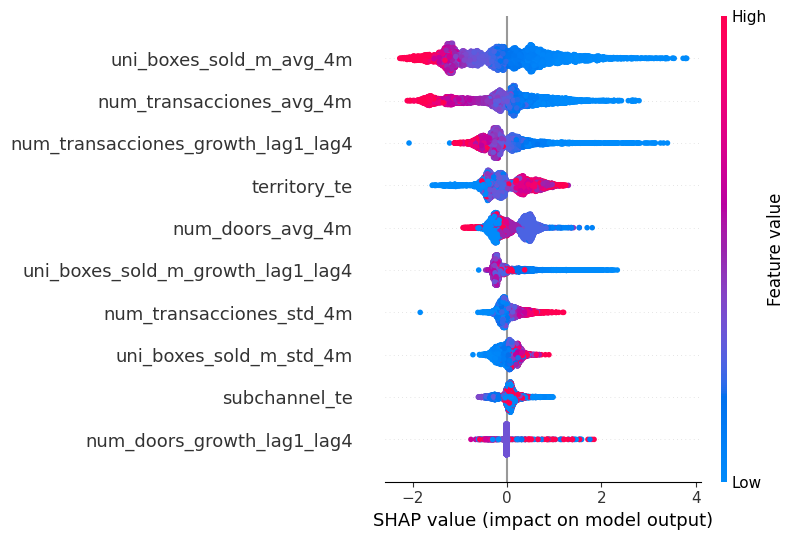


Ejemplo cliente de mayor riesgo:
Probabilidad de churn: 99.78%


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,variable,valor_cliente,impacto_shap,impacto_abs
3,num_transacciones_growth_lag1_lag4,-0.923077,2.957534,2.957534
0,uni_boxes_sold_m_avg_4m,8.552300,1.492869,1.492869
4,uni_boxes_sold_m_growth_lag1_lag4,-0.997853,1.294155,1.294155
9,num_doors_growth_lag1_lag4,0.999999,1.289993,1.289993
8,num_doors_avg_4m,1.250000,1.153727,1.153727
2,num_transacciones_avg_4m,6.500000,0.951663,0.951663
7,subchannel_te,0.005226,0.165002,0.165002
1,territory_te,0.006957,-0.074849,0.074849
6,uni_boxes_sold_m_std_4m,10.161979,-0.049634,0.049634
5,num_transacciones_std_4m,5.196152,-0.000987,0.000987



Archivos exportados:
- resultados_churn_validacion.csv
- importancia_variables.csv
- threshold_results.csv
- resumen_estrategias_intervencion.csv
- resumen_riesgo.csv
- clientes_prioritarios_churn.csv


In [ ]:
# ============================================================
# MODELO FINAL CHURN
# Logistic Regression + LightGBM + SHAP + Estrategias de intervención
# Compatible con train_model_ready, test_model_ready y top_features
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import lightgbm as lgb

# ------------------------------------------------------------
# 1. Variables seleccionadas
# ------------------------------------------------------------

cols_no_model = [
    "customer_id",
    "calmonth",
    "target"
]

if "top_features" in globals():

    selected_features = [
        col for col in top_features
        if col in train_model_ready.columns
        and col not in cols_no_model
    ]

else:

    selected_features = [
        col for col in train_model_ready.columns
        if col not in cols_no_model
    ]

print("="*60)
print("VARIABLES UTILIZADAS")
print("="*60)
print(selected_features)
print("Número de variables:", len(selected_features))

# ------------------------------------------------------------
# 2. Train/Test
# ------------------------------------------------------------

X_train = train_model_ready[selected_features].copy()
y_train = train_model_ready["target"].copy()

X_test = test_model_ready[selected_features].copy()
y_test = test_model_ready["target"].copy()

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)

X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

# ------------------------------------------------------------
# 3. BASELINE - Logistic Regression
# ------------------------------------------------------------

print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_proba = logistic_model.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_proba >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, logistic_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, logistic_proba), 4))

print("\nClassification report Logistic Regression:")
print(classification_report(y_test, logistic_pred))

# ------------------------------------------------------------
# 4. LIGHTGBM
# ------------------------------------------------------------

print("\n" + "="*60)
print("LIGHTGBM")
print("="*60)

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(100)
    ]
)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", round(roc_auc_score(y_test, lgb_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, lgb_proba), 4))

# ------------------------------------------------------------
# 5. BÚSQUEDA DE THRESHOLD
# ------------------------------------------------------------

print("\n" + "="*60)
print("THRESHOLD TUNING")
print("="*60)

thresholds = [
    0.005, 0.01, 0.02, 0.03, 0.05,
    0.10, 0.15, 0.20, 0.30, 0.50
]

threshold_results = []

for t in thresholds:

    preds = (lgb_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "clientes_marcados": int(preds.sum()),
        "porcentaje_marcado": round(preds.mean() * 100, 2)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax(),
    "threshold"
]

print("\nMejor threshold por F1:", best_threshold)

# ------------------------------------------------------------
# 6. MÉTRICAS FINALES
# ------------------------------------------------------------

final_pred = (lgb_proba >= best_threshold).astype(int)

print("\n" + "="*60)
print("RESULTADOS FINALES LIGHTGBM")
print("="*60)

print(classification_report(y_test, final_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, final_pred))

# ------------------------------------------------------------
# 7. IMPORTANCIA DE VARIABLES
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "variable": selected_features,
    "importance": lgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\nTOP VARIABLES")
display(importance_df)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["variable"].head(25)[::-1],
    importance_df["importance"].head(25)[::-1]
)

plt.title("Top 25 Variables - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. TABLA DE RIESGO + ESTRATEGIAS DE INTERVENCIÓN
# ------------------------------------------------------------

results_test = test_model_ready.copy()

results_test["churn_probability"] = lgb_proba
results_test["churn_probability_pct"] = (
    results_test["churn_probability"] * 100
).round(2)

# Predicción final usando mejor threshold por F1
results_test["predicted_churn"] = final_pred

# Predicciones por estrategia
results_test["pred_agresiva_010"] = (
    results_test["churn_probability"] >= 0.10
).astype(int)

results_test["pred_balanceada_030"] = (
    results_test["churn_probability"] >= 0.30
).astype(int)

results_test["pred_conservadora_050"] = (
    results_test["churn_probability"] >= 0.50
).astype(int)

# Nivel de riesgo operativo
def asignar_riesgo(prob):

    if prob >= 0.50:
        return "Alto"

    elif prob >= 0.30:
        return "Medio"

    elif prob >= 0.10:
        return "Bajo vigilado"

    else:
        return "Bajo"

results_test["risk_level"] = (
    results_test["churn_probability"]
    .apply(asignar_riesgo)
)

# Acción recomendada
def recomendar_intervencion(risk_level):

    if risk_level == "Alto":
        return "Visita comercial inmediata + oferta personalizada"

    elif risk_level == "Medio":
        return "Seguimiento telefónico + promoción preventiva"

    elif risk_level == "Bajo vigilado":
        return "Campaña digital o monitoreo semanal"

    else:
        return "Sin intervención inmediata"

results_test["recommended_action"] = (
    results_test["risk_level"]
    .apply(recomendar_intervencion)
)

# Resumen de estrategias
estrategias = {
    "Agresiva": 0.10,
    "Balanceada": 0.30,
    "Conservadora": 0.50
}

resumen_estrategias = []

for nombre, threshold in estrategias.items():

    preds = (results_test["churn_probability"] >= threshold).astype(int)

    tp = int(((preds == 1) & (y_test == 1)).sum())
    total_churns = int((y_test == 1).sum())
    clientes_intervenir = int(preds.sum())

    resumen_estrategias.append({
        "estrategia": nombre,
        "threshold": threshold,
        "clientes_a_intervenir": clientes_intervenir,
        "porcentaje_clientes": round(preds.mean() * 100, 2),
        "churns_detectados": tp,
        "total_churns_reales": total_churns,
        "recall_churn": round(tp / max(total_churns, 1), 4),
        "precision": round(tp / max(clientes_intervenir, 1), 4)
    })

resumen_estrategias = pd.DataFrame(resumen_estrategias)

print("\nRESUMEN DE ESTRATEGIAS DE INTERVENCIÓN")
display(resumen_estrategias)

# Resumen por nivel de riesgo
resumen_riesgo = (
    results_test
    .groupby("risk_level")
    .agg(
        clientes=("customer_id", "count"),
        prob_promedio=("churn_probability_pct", "mean"),
        churn_real=("target", "sum")
    )
    .reset_index()
)

resumen_riesgo["prob_promedio"] = (
    resumen_riesgo["prob_promedio"]
    .round(2)
)

print("\nRESUMEN POR NIVEL DE RIESGO")
display(resumen_riesgo)

print("\nCLIENTES DE MAYOR RIESGO")

clientes_prioritarios = (
    results_test
    .sort_values("churn_probability", ascending=False)
    .head(50)
)

display(
    clientes_prioritarios[
        [
            "customer_id",
            "calmonth",
            "churn_probability_pct",
            "risk_level",
            "recommended_action",
            "target"
        ]
    ]
)

# ------------------------------------------------------------
# 9. SHAP
# ------------------------------------------------------------

try:

    import shap

    print("\n" + "="*60)
    print("SHAP")
    print("="*60)

    X_shap = X_test.sample(
        n=min(5000, len(X_test)),
        random_state=42
    )

    explainer = shap.TreeExplainer(lgb_model)

    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(
        shap_values_plot,
        X_shap
    )

    def explicar_cliente(customer_index):

        cliente = X_test.loc[[customer_index]]

        prob = lgb_model.predict_proba(cliente)[:, 1][0]

        shap_cliente = explainer.shap_values(cliente)

        if isinstance(shap_cliente, list):
            shap_cliente_values = shap_cliente[1][0]
        else:
            shap_cliente_values = shap_cliente[0]

        razones = pd.DataFrame({
            "variable": cliente.columns,
            "valor_cliente": cliente.iloc[0].values,
            "impacto_shap": shap_cliente_values
        })

        razones["impacto_abs"] = razones["impacto_shap"].abs()

        razones = razones.sort_values(
            "impacto_abs",
            ascending=False
        )

        print(f"Probabilidad de churn: {prob*100:.2f}%")

        return razones.head(10)

    print("\nEjemplo cliente de mayor riesgo:")

    cliente_demo = (
        results_test
        .sort_values(
            "churn_probability",
            ascending=False
        )
        .index[0]
    )

    display(explicar_cliente(cliente_demo))

except Exception as e:

    print("SHAP no pudo ejecutarse:")
    print(e)

# ------------------------------------------------------------
# 10. EXPORTAR
# ------------------------------------------------------------

results_test.to_csv(
    "resultados_churn_validacion.csv",
    index=False
)

importance_df.to_csv(
    "importancia_variables.csv",
    index=False
)

threshold_results.to_csv(
    "threshold_results.csv",
    index=False
)

resumen_estrategias.to_csv(
    "resumen_estrategias_intervencion.csv",
    index=False
)

resumen_riesgo.to_csv(
    "resumen_riesgo.csv",
    index=False
)

clientes_prioritarios.to_csv(
    "clientes_prioritarios_churn.csv",
    index=False
)

print("\nArchivos exportados:")
print("- resultados_churn_validacion.csv")
print("- importancia_variables.csv")
print("- threshold_results.csv")
print("- resumen_estrategias_intervencion.csv")
print("- resumen_riesgo.csv")
print("- clientes_prioritarios_churn.csv")

In [ ]:
# ============================================================
# VALIDACIÓN DEL SPLIT TRAIN/TEST POR CLIENTE
# ============================================================

clientes_train = set(train_model_ready["customer_id"])
clientes_test = set(test_model_ready["customer_id"])

clientes_repetidos = clientes_train.intersection(clientes_test)

print("Clientes en train:", len(clientes_train))
print("Clientes en test:", len(clientes_test))
print("Clientes repetidos entre train y test:", len(clientes_repetidos))

if len(clientes_repetidos) == 0:
    print("Correcto: ningún cliente aparece en ambos conjuntos.")
else:
    print("Alerta: hay clientes repetidos entre train y test.")

Clientes en train: 201913
Clientes en test: 22435
Clientes repetidos entre train y test: 0
Correcto: ningún cliente aparece en ambos conjuntos.


In [ ]:
# ============================================================
# VALIDACIÓN DE DISTRIBUCIÓN DEL TARGET
# ============================================================

print("Churn rate train:")
print(y_train.mean())

print("\nChurn rate test:")
print(y_test.mean())

print("\nConteo train:")
print(y_train.value_counts(normalize=True))

print("\nConteo test:")
print(y_test.value_counts(normalize=True))

Churn rate train:
0.007635614786033462

Churn rate test:
0.0074941211805987975

Conteo train:
target
0    0.992364
1    0.007636
Name: proportion, dtype: float64

Conteo test:
target
0    0.992506
1    0.007494
Name: proportion, dtype: float64


In [ ]:
validacion_split = pd.DataFrame({
    "conjunto": ["Train", "Test"],
    "filas": [len(train_model_ready), len(test_model_ready)],
    "clientes_unicos": [
        train_model_ready["customer_id"].nunique(),
        test_model_ready["customer_id"].nunique()
    ],
    "churn_rate": [
        train_model_ready["target"].mean(),
        test_model_ready["target"].mean()
    ],
    "churns": [
        train_model_ready["target"].sum(),
        test_model_ready["target"].sum()
    ]
})

display(validacion_split)

,conjunto,filas,clientes_unicos,churn_rate,churns
0,Train,3679337,201913,0.007636,28094
1,Test,409521,22435,0.007494,3069


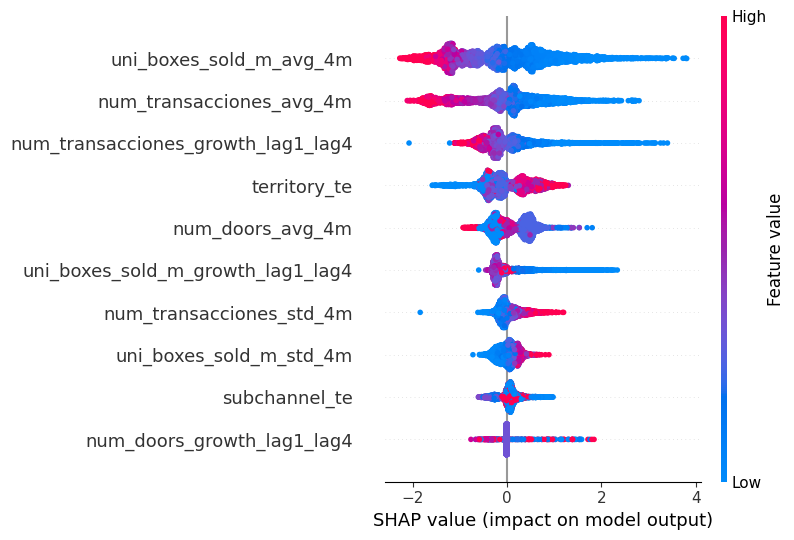

In [ ]:
shap.summary_plot(
    shap_values_plot,
    X_shap
)

In [ ]:
# ------------------------------------------------------------
# Exportar importancia SHAP promedio
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "variable": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values_plot).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance.to_csv(
    "shap_importance.csv",
    index=False
)

print("Archivo exportado: shap_importance.csv")
display(shap_importance)

Archivo exportado: shap_importance.csv


,variable,mean_abs_shap
0,uni_boxes_sold_m_avg_4m,0.857141
1,num_transacciones_avg_4m,0.663247
2,num_transacciones_growth_lag1_lag4,0.410452
3,territory_te,0.395501
4,num_doors_avg_4m,0.322088
5,uni_boxes_sold_m_growth_lag1_lag4,0.293475
6,num_transacciones_std_4m,0.175022
7,uni_boxes_sold_m_std_4m,0.164698
8,subchannel_te,0.153019
9,num_doors_growth_lag1_lag4,0.036515


In [ ]:
# ============================================================
# GUARDAR MODELO + ARTEFACTOS PARA EL MONITOR
# ============================================================

import joblib

# 1. Columnas finales usadas por el modelo
feature_columns = selected_features.copy()

# 2. Recalcular mapas de Target Encoding desde train_df original
global_mean = train_df["target"].mean()

def crear_mapa_target_encoding(train, column, target="target", alpha=20):
    stats = train.groupby(column)[target].agg(["mean", "count"])

    smooth = (
        stats["count"] * stats["mean"] + alpha * global_mean
    ) / (
        stats["count"] + alpha
    )

    return smooth.to_dict()

territory_te_map = crear_mapa_target_encoding(
    train_df,
    "territory_d"
)

subchannel_te_map = crear_mapa_target_encoding(
    train_df,
    "comercial_subchannel_d"
)

# 3. Orden ordinal usado
orden_size = [
    "Mini",
    "Pequeño",
    "Mediano",
    "Grande",
    "Gigante"
]

size_map = {
    size: i for i, size in enumerate(orden_size)
}

# 4. Variables usadas para ventana móvil
behavioral_vars = [
    "num_transacciones",
    "uni_boxes_sold_m",
    "num_coolers",
    "num_doors"
]

# 5. Guardar modelo
joblib.dump(lgb_model, "modelo_churn.pkl")

# 6. Guardar columnas
joblib.dump(feature_columns, "feature_columns.pkl")

# 7. Guardar preprocesamiento
preprocessing_artifacts = {
    "feature_columns": feature_columns,
    "behavioral_vars": behavioral_vars,
    "territory_te_map": territory_te_map,
    "subchannel_te_map": subchannel_te_map,
    "global_mean": global_mean,
    "size_map": size_map
}

joblib.dump(preprocessing_artifacts, "preprocessing_artifacts.pkl")

print("Archivos guardados:")
print("- modelo_churn.pkl")
print("- feature_columns.pkl")
print("- preprocessing_artifacts.pkl")